# Project: Neutrino Portal at the Muon Collider

## Load Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import pathlib
import ast
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json

## Calculate Observables

-  this function reads the particles in a csv file and exports a data frame

In [12]:
data = pd.read_csv("output_events_NC_numu/events_22.53.csv.zip")

In [13]:
data 

,ievent,iparticle,truth_energy,pid,px,py,pz,e,parent_pid1,parent_pid2
0,NaN,0,22.53,14,-0.934,-0.835,7.702,7.803,14,14
1,NaN,1,22.53,211,-0.282,-0.034,1.208,1.249,4,2203
2,NaN,2,22.53,-211,1.316,-0.109,2.203,2.572,-411,90
3,NaN,3,22.53,-13,-0.311,0.066,0.355,0.488,4122,90
4,NaN,4,22.53,14,0.223,0.523,4.047,4.087,4122,90
...,...,...,...,...,...,...,...,...,...,...
27676,NaN,4,22.53,-14,-0.884,-0.032,2.474,2.627,-421,90
27677,NaN,5,22.53,321,0.044,-0.085,0.677,0.843,-421,90
27678,NaN,6,22.53,-13,0.262,0.260,3.125,3.149,411,90
27679,NaN,7,22.53,14,-0.253,-0.503,3.075,3.126,411,90


- function that fixes missing ievent entries

In [14]:
def fix_dataframe(data):

    # Initialize the column 'ievent' with zeros
    data['ievent'] = 0
    # Variable to keep track of the increment for column 'ievent'
    counter = 0
    # Loop through the DataFrame rows
    for index, row in data.iterrows():
        if row['iparticle'] == 0: counter += 1
        data.at[index, 'ievent'] = counter
    #return
    return data

In [15]:
data = fix_dataframe(data)
data

,ievent,iparticle,truth_energy,pid,px,py,pz,e,parent_pid1,parent_pid2
0,1,0,22.53,14,-0.934,-0.835,7.702,7.803,14,14
1,1,1,22.53,211,-0.282,-0.034,1.208,1.249,4,2203
2,1,2,22.53,-211,1.316,-0.109,2.203,2.572,-411,90
3,1,3,22.53,-13,-0.311,0.066,0.355,0.488,4122,90
4,1,4,22.53,14,0.223,0.523,4.047,4.087,4122,90
...,...,...,...,...,...,...,...,...,...,...
27676,2368,4,22.53,-14,-0.884,-0.032,2.474,2.627,-421,90
27677,2368,5,22.53,321,0.044,-0.085,0.677,0.843,-421,90
27678,2368,6,22.53,-13,0.262,0.260,3.125,3.149,411,90
27679,2368,7,22.53,14,-0.253,-0.503,3.075,3.126,411,90


- function that evaulates all necessary obseravbles for each event

In [6]:
def calculate_observables(data):
    events = []
    grouped_data = data.groupby('ievent')

    for ievent, evt in grouped_data:
        # Reset or initialize variables for each event
        e_mu_minus, e_mu_plus, has_charm, e_em, e_visible, ptx, pty, ht = 0, 0, 0, 0, 0, 0, 0, 0
        
        # Iterate over particles in the event
        for _, row in evt.iterrows():
            truth_energy, pid, px, py, pz, e  = row[2], row[3], row[4], row[5], row[6], row[7]
            parent_pid1 = row[8]
            
            # Check for charm particles
            if abs(parent_pid1) in {411, 421, 431, 4122}: 
                has_charm = 1
            
            # Update energies for mu- and mu+
            if pid == 13: e_mu_minus = max(e, e_mu_minus)
            elif pid == -13: e_mu_plus = max(e, e_mu_plus)
            
            # Sum EM and visible energy
            if abs(pid) in {22, 11}: 
                e_em += e
            if abs(pid) not in {12, 14, 16}: 
                e_visible += e
                ptx += px
                pty += py
                ht += np.sqrt(px**2 + py**2)
        
        # Calculate missing pT
        pt_mis = -np.sqrt(ptx**2 + pty**2)
        
        # Append event observables
        events.append([ievent, truth_energy, e_mu_minus, e_mu_plus, e_em, has_charm, e_visible, pt_mis, ht])

    # Construct DataFrame from results
    columns = ['ievent', 'truth_energy', 'e_mu_minus', 'e_mu_plus', 'e_em', 'has_charm', 'e_visible', 'pt_mis', 'ht']
    observables = pd.DataFrame(events, columns=columns)
    
    return observables


In [7]:
%%time
observables = calculate_observables(data)

CPU times: user 990 ms, sys: 16.2 ms, total: 1.01 s
Wall time: 1.08 s


In [8]:
observables

,ievent,truth_energy,e_mu_minus,e_mu_plus,e_em,has_charm,e_visible,pt_mis,ht
0,1,22.53,0.000,0.488,0.000,1,11.622,-0.775126,2.910989
1,2,22.53,1.261,0.324,6.450,0,21.574,-1.154859,2.556138
2,3,22.53,0.853,4.620,1.724,1,18.463,-1.002941,2.973211
3,4,22.53,1.275,0.539,1.218,0,4.188,-1.296556,1.546107
4,5,22.53,0.534,2.197,0.000,1,16.143,-1.784818,2.795638
...,...,...,...,...,...,...,...,...,...
2363,2364,22.53,0.000,1.484,2.573,1,19.545,-1.125340,3.060091
2364,2365,22.53,0.135,0.250,0.398,0,3.141,-0.623046,0.826662
2365,2366,22.53,1.190,1.634,1.204,1,20.523,-0.915495,2.749552
2366,2367,22.53,0.000,4.545,4.098,1,15.692,-1.280407,2.987993


<AxesSubplot:xlabel='e_mu_minus', ylabel='Count'>

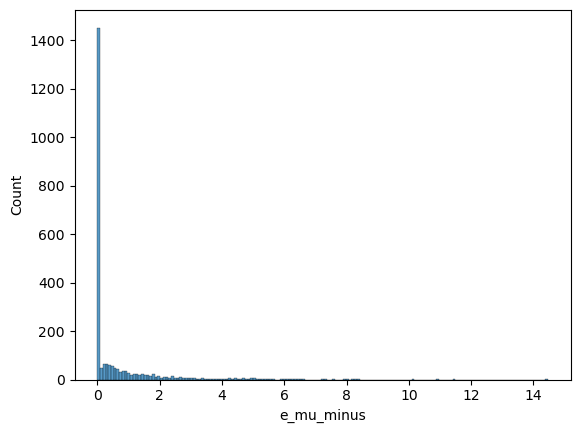

In [9]:
sns.histplot(observables, x='e_mu_minus')

- let us systematically calculate obvservables for all files

In [10]:
# List of energies
energies = [
    14.21, 17.90, 22.53, 28.37, 35.71, 44.964, 56.60, 71.26, 89.71, 
    112.94, 142.19, 179.00, 225.35, 283.70, 357.16, 449.64, 566.07, 712.64, 897.16,
    1129.46, 1421.90, #1790.077754, 2253.574373, 2837.082046, 3571.674683,
    #4496.472021, 5660.722891, 7126.427896, 8971.641174
] 
processes = ["CC_numu", "CC_nuebar", "NC_numu", "NC_nuebar"]

# Loop through all energies
for process in processes: 
    for energy in energies:
        print (process, energy)
        data = pd.read_csv("output_events_"+process+"/events_"+str(energy)+".csv.zip")
        if np.isnan(data['ievent'].loc[0]): data = fix_dataframe(data)
        observables = calculate_observables(data)
        csv_file = "output_events_"+process+"/observables_"+str(energy)+".csv.zip"
        observables.to_csv(csv_file, index=False, compression='zip')

CC_numu 14.21
CC_numu 17.9
CC_numu 22.53
CC_numu 28.37
CC_numu 35.71
CC_numu 44.964
CC_numu 56.6
CC_numu 71.26


KeyboardInterrupt: 

## Analysis

### Load all events 

Explanation for file format of MC_-14_3TeV_with_cut_with_final.txt: The first column in the file is energy in GeV. The second column is the flux of $\nu_{\mu}$ per year. The third column is the flux of $\bar\nu_{e}$ per year. The remaining columns are for cross sections of the different charged and neutral current processes for $\nu_{\mu}$ and $\bar\nu_{e}$ in units of $cm^{2}$. The cross sections have been obtained using pythia.SigmaGen() and compared with cross-section produced by GENIE. 

To get the event weight, we divide the number of interacting neutrinos per year by the number of monte carlo events generated to normalize it. 
\begin{equation}
N{\nu}_{\mu} =\frac{\sigma\times\rho\times l_{det}\times10^{-36}\times N_{inc}}{m_{p}} 
\end{equation}

Here, $\sigma\times10^{-36}$ is the cross section in $cm^{2}$, $\rho$ is the density of iron in $g/cm^{3}$, $l_{det}$ is the length of detector in centimeters, $N_{inc}$ is the number of incident neutrinos per year and $m_p$ is the mass of proton in gram. 

In [2]:
def load_everything(scaling_file='MC_-14_3TeV_with_cut_with_final.txt'):
    
    #initialize numbers
    rho = 7.874            # density of iron in g/cm3
    mass = 1.67e-24        # mass of proton in g 
    l_det = 4.0425         # length of detector for iron for 10 kg in cm
    mul = rho*l_det/mass   # area density, in 1/cm2
    #nevent = 1e7           # No. of MC events 

    #initialize output 
    all_data = None
    
    #import data on fluxes and cross sections
    scaling_data = pd.read_csv(scaling_file, delim_whitespace=True) 
    scaling_data['energy'] = round(scaling_data['energy'],0)
    
    #loop over datasets 
    datasets = ['NC_nuebar', 'CC_nuebar', 'CC_numu', 'NC_numu']
    for dataset in datasets:
        
        # get all files and loop over them
        dirname = 'output_events_' + dataset  
        directory = pathlib.Path(dirname)
        files = sorted(directory.rglob('observables_*.csv.zip'))
        
        #import data on generated event rates
        generated_data_name = dirname+"/generated_events.json"
        with open(generated_data_name, "r") as f: generated_data_raw = json.load(f)
        generated_data = {int(float(key)): value for key, value in generated_data_raw.items()}

        for file in files:
            #logging
            #print("load file: "+ str(file))
            
            # get beam energy
            energy = float(str(file).split('_')[-1].replace('.csv.zip', ''))
                
            # load data, get observables
            observables = pd.read_csv(str(file))
            observables['set'] = dataset
            print("load file: "+ str(file), len(observables))
            
            ### obtain number of events (allows for different nevents for different energies)
            nevent = generated_data[int(energy)]
            
            # calculate scaling factor            
            scaling_row = scaling_data[scaling_data['energy'] == round(energy,0)]
            
            cross_section = scaling_row[dataset].values[0]
            flux = scaling_row[dataset[3:]+"_flux"].values[0]  
            weight = ((cross_section * flux * mul)/nevent)    
            observables['weight'] = weight
            
            # combine data
            if all_data is None: all_data = observables
            else:all_data = pd.concat([all_data, observables])
    
    return all_data.reset_index(drop=True)


In [3]:
data0 = load_everything(scaling_file='MC_-14_3TeV_with_cut_with_final.txt')

load file: output_events_NC_nuebar/observables_112.94.csv.zip 15598
load file: output_events_NC_nuebar/observables_1129.46.csv.zip 59730
load file: output_events_NC_nuebar/observables_14.21.csv.zip 1162
load file: output_events_NC_nuebar/observables_142.19.csv.zip 18674
load file: output_events_NC_nuebar/observables_1421.9.csv.zip 65383
load file: output_events_NC_nuebar/observables_17.9.csv.zip 1838
load file: output_events_NC_nuebar/observables_179.0.csv.zip 21699
load file: output_events_NC_nuebar/observables_22.53.csv.zip 2717
load file: output_events_NC_nuebar/observables_225.35.csv.zip 25585
load file: output_events_NC_nuebar/observables_28.37.csv.zip 3673
load file: output_events_NC_nuebar/observables_283.7.csv.zip 29544
load file: output_events_NC_nuebar/observables_35.71.csv.zip 4919
load file: output_events_NC_nuebar/observables_357.16.csv.zip 33655
load file: output_events_NC_nuebar/observables_44.964.csv.zip 6642
load file: output_events_NC_nuebar/observables_449.64.csv.zip

### Get event rates and histograms after cuts

- function that prints  

In [4]:
def get_rates(data, header=None):
    
    # print header
    if header is not None: print(header+":")
    
    # get event rates and MC staistics for all processes
    for dataset in ['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar']:
        n_mc = len(data[data['set']==dataset])
        n_real = sum(data[data['set']==dataset]['weight'])
        print ("   "+dataset+": " + str(n_real)+ " (N_MC = "+str(n_mc)+")")
               
def get_stacked_histogram(data, observable, bins, xlabel, xlog=False):
               
    # setup figure
    datasets = {'CC_numu':"dodgerblue", 'CC_nuebar':"blue", 'NC_numu':"red", 'NC_nuebar':"firebrick"}
    labels = {'CC_numu':r"CC $\nu_\mu$", 'CC_nuebar':r"CC $\nu_e$", 'NC_numu':r"NC $\nu_\mu$", 'NC_nuebar':r"NC $\nu_e$"}
    matplotlib.rcParams.update({'font.size': 14})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(12,4.5))
    
    #plot linear 
    ax1 = plt.subplot(1,2,1)   
    ax2 = plt.subplot(1,2,2)   
    for dataset in datasets.keys():
        
        #get stuff
        subset = data[data['set']==dataset]
        x, w = subset[observable], subset['weight']
        c, l = datasets[dataset], labels[dataset]
        
        # linear y-axis   
        ax1.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l)
        
        # log y axis
        ax2.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l)
    
    # linear y-axis           
    if xlog: ax1.set_xscale("log")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(r"Interacting Neutrinos")
    ax1.legend(frameon=False, labelspacing=0, fontsize=14)
          
    # log y axis     
    if xlog: ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(r"Interacting Neutrinos")
    ax2.legend(frameon=False, labelspacing=0, fontsize=14)
         
    #finalize
    plt.tight_layout()
    plt.show()

### 1.  select data with mu+ with E>10GeV

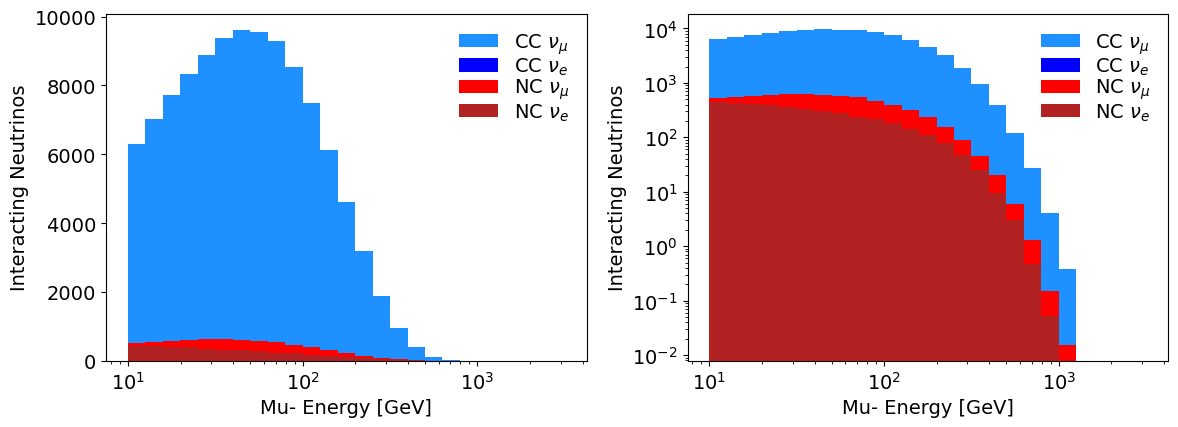

In [5]:
data = data0.copy()
get_stacked_histogram(
    data=data, 
    observable="e_mu_plus", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="Mu- Energy [GeV]", 
    xlog=True,
)

In [6]:
data = data[data['e_mu_plus']>100]
get_rates(data, header = r"Events with $E_{\mu^+} >100$ GeV")

Events with $E_{\mu^+} >100$ GeV:
   CC_numu: 24769.313067051233 (N_MC = 173653)
   CC_nuebar: 35.89926041989695 (N_MC = 718)
   NC_numu: 1258.427096940414 (N_MC = 29193)
   NC_nuebar: 599.2086322395897 (N_MC = 32951)


### 2. Veto events with mu- with E>100 GeV

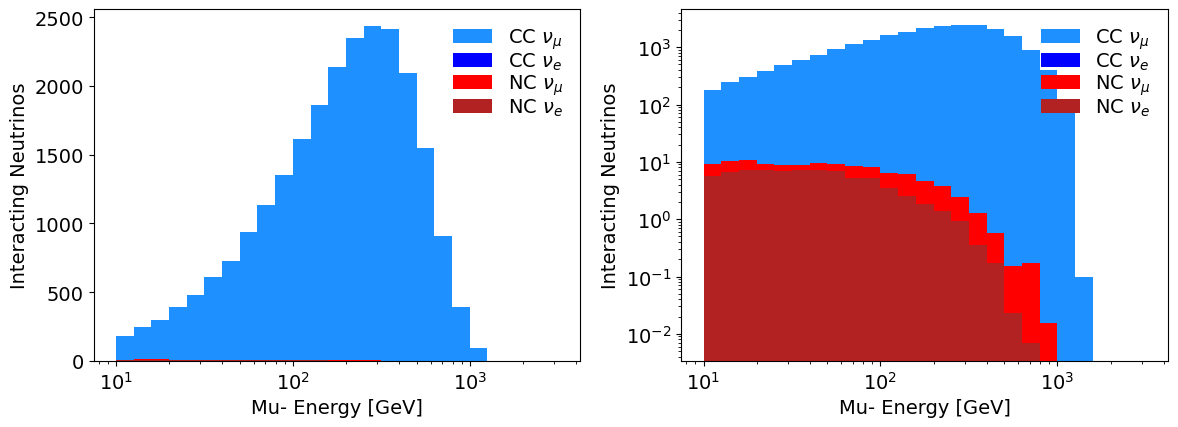

In [7]:
get_stacked_histogram(
    data=data, 
    observable="e_mu_minus", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="Mu- Energy [GeV]", 
    xlog=True,
)

In [8]:
data = data[data['e_mu_minus']<10]
get_rates(data, header = r"Events with $E_{\mu^-} <100$ GeV")

Events with $E_{\mu^-} <100$ GeV:
   CC_numu: 578.3676322484821 (N_MC = 4121)
   CC_nuebar: 4.667198573878111 (N_MC = 99)
   NC_numu: 1140.0150569415835 (N_MC = 26358)
   NC_nuebar: 523.1678201972155 (N_MC = 28601)


### 3. EM energy

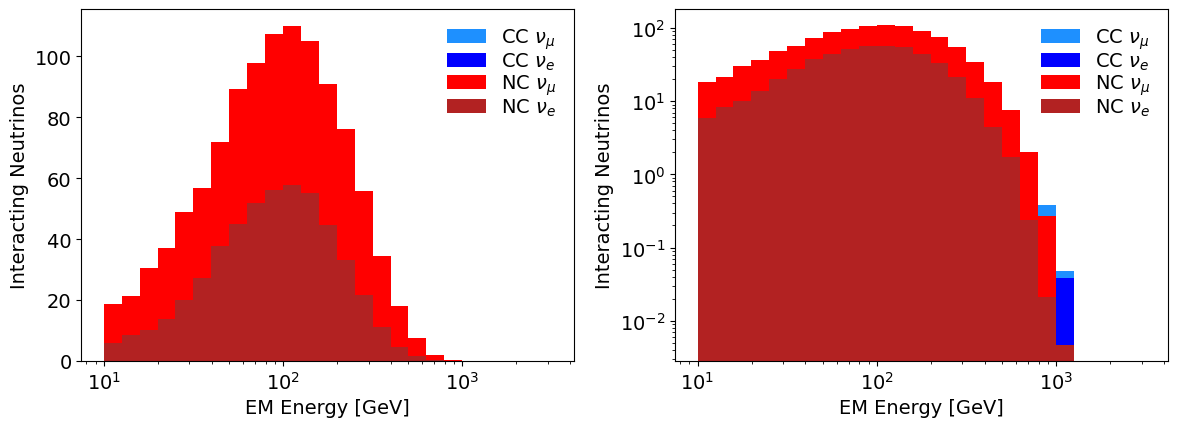

In [9]:
get_stacked_histogram(
    data=data, 
    observable="e_em", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="EM Energy [GeV]", 
    xlog=True,
)

In [10]:
data = data[data['e_em']<200]
get_rates(data, header = r"Events with $E_EM <200$ GeV")

Events with $E_EM <200$ GeV:
   CC_numu: 483.93918158074814 (N_MC = 3460)
   CC_nuebar: 0.7561780183957334 (N_MC = 16)
   NC_numu: 946.0855290339648 (N_MC = 20619)
   NC_nuebar: 450.9661924832948 (N_MC = 22300)


### 4. Charm Veto

In [11]:
veto_prob = 0.8
data.loc[:, 'random'] = np.random.random(data.shape[0])
data = data[(data['has_charm']==1) & (data['random']<veto_prob)]
get_rates(data, header = r"Events without charm")

Events without charm:
   CC_numu: 390.22999955698305 (N_MC = 2782)
   CC_nuebar: 0.4296977336133155 (N_MC = 7)
   NC_numu: 746.2708015016124 (N_MC = 16287)
   NC_nuebar: 346.5637787846954 (N_MC = 17242)


/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_69287/343797983.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'random'] = np.random.random(data.shape[0])
